# Tiny crater DQN test - train, fine-tune, and visualize test paths

Structure of this notebook:
1. Train an agent on 1 randomized crater
2. Test it (batch of 12) on fresh 1-crater maps, and on fresh 2-crater maps (harder than what it trained on)
3. Fine-tune the SAME agent further on 2-crater maps
4. Test it again on 2-crater maps to see if fine-tuning actually helped

Run cells top to bottom. Each plot uses `display(fig)` so it renders inline without needing `plt.show()`.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline

from main import TinyFixedEnvironment
from agent import DQNAgent
from environment import GOAL_REWARD, CRATER_PENALTY

## Phase 1: train on 1 crater
`randomize_crater=True` - a new crater center + radius every episode, so the agent can't just memorize one fixed path.

In [6]:
env = TinyFixedEnvironment(randomize_crater=True)
agent = DQNAgent(input_size=30, num_actions=4, target_update_freq=50, batch_size=32)

episodes = 1600
reward_history = []
outcome_history = []

for ep in range(episodes):
    state = env.reset()
    total_reward = 0.0
    done = False
    outcome = "timed_out"
    while not done:
        action = agent.choose_action(state)
        next_state, reward, done, info = env.step(action)
        agent.replay_buffer.add(state, action, reward, next_state, done)
        agent.train_step()
        state = next_state
        total_reward += reward
        if done:
            if reward == GOAL_REWARD:
                outcome = "reached_goal"
            elif reward == CRATER_PENALTY:
                outcome = "hit_crater"
    agent.decay_epsilon()
    reward_history.append(total_reward)
    outcome_history.append(outcome)

    if ep % 40 == 0:
        recent = outcome_history[-40:]
        success_rate = recent.count("reached_goal") / len(recent) * 100
        print(f"Episode {ep}/{episodes} | Reward: {total_reward:.1f} | success_rate(last40): {success_rate:.0f}%")

print("phase 1 (1-crater) training done")

Episode 0/1600 | Reward: -95.2 | success_rate(last40): 0%
Episode 40/1600 | Reward: 509.5 | success_rate(last40): 12%
Episode 80/1600 | Reward: 509.5 | success_rate(last40): 25%
Episode 120/1600 | Reward: 509.2 | success_rate(last40): 62%
Episode 160/1600 | Reward: -93.0 | success_rate(last40): 52%
Episode 200/1600 | Reward: 509.0 | success_rate(last40): 52%
Episode 240/1600 | Reward: 509.2 | success_rate(last40): 90%
Episode 280/1600 | Reward: 509.5 | success_rate(last40): 85%
Episode 320/1600 | Reward: 509.5 | success_rate(last40): 78%
Episode 360/1600 | Reward: 509.5 | success_rate(last40): 82%
Episode 400/1600 | Reward: 509.5 | success_rate(last40): 80%
Episode 440/1600 | Reward: -98.7 | success_rate(last40): 80%
Episode 480/1600 | Reward: 509.1 | success_rate(last40): 78%
Episode 520/1600 | Reward: -44.0 | success_rate(last40): 75%
Episode 560/1600 | Reward: 509.1 | success_rate(last40): 92%
Episode 600/1600 | Reward: 509.1 | success_rate(last40): 88%
Episode 640/1600 | Reward: 50

## Phase 1 reward curve

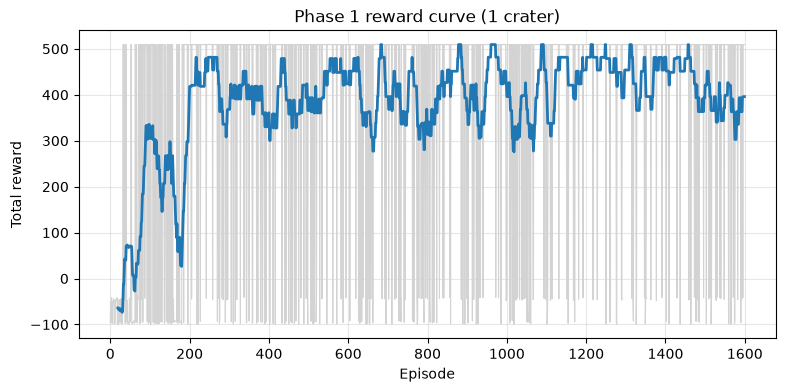

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(reward_history, color="lightgray", linewidth=0.8)
window = 20
rolling = np.convolve(reward_history, np.ones(window) / window, mode="valid")
ax.plot(range(window - 1, episodes), rolling, color="tab:blue", linewidth=2)
ax.set_title("Phase 1 reward curve (1 crater)")
ax.set_xlabel("Episode"); ax.set_ylabel("Total reward"); ax.grid(alpha=0.3)
display(fig)

## Test the phase-1 agent on fresh, unseen 1-crater maps

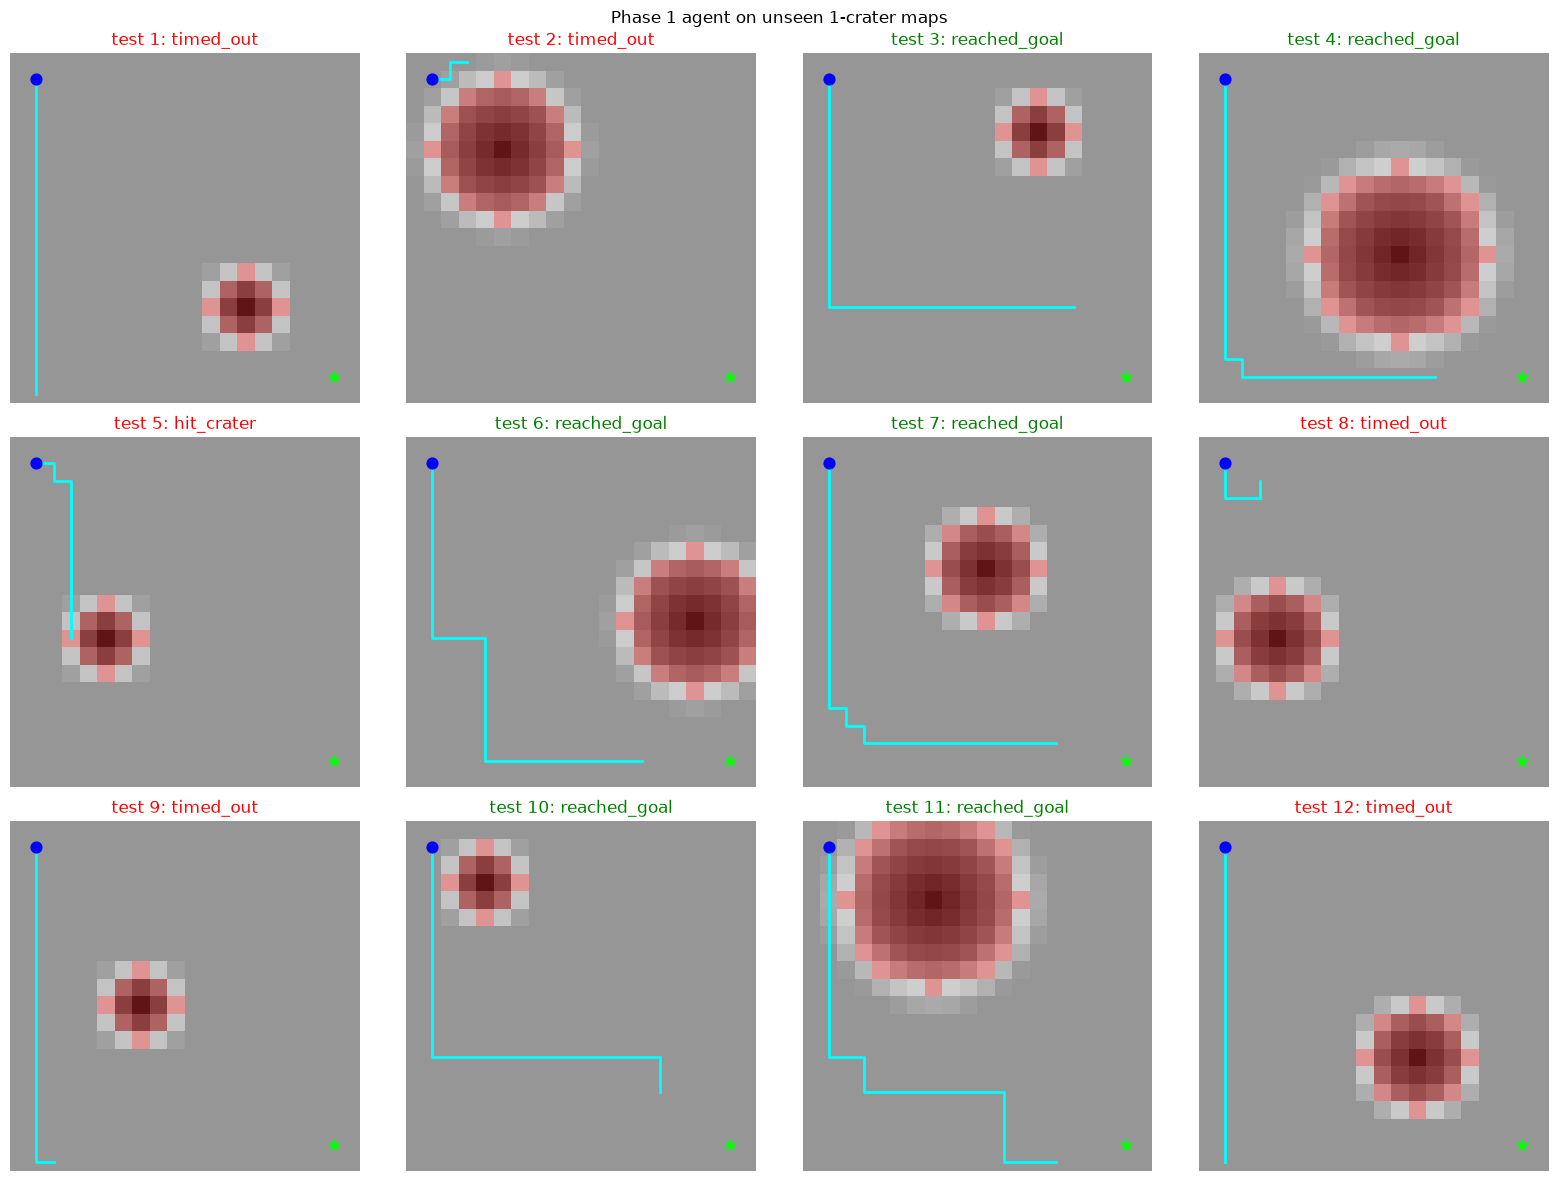

6/12 reached the goal (50%) - Phase 1 agent on unseen 1-crater maps
['timed_out', 'timed_out', 'reached_goal', 'reached_goal', 'hit_crater', 'reached_goal', 'reached_goal', 'timed_out', 'timed_out', 'reached_goal', 'reached_goal', 'timed_out']


In [8]:
def run_batch_test(agent, test_env, n_tests=12, title="test"):
    """Runs n_tests fresh greedy episodes on test_env, plots every path in
    a grid, and returns the list of outcomes."""
    agent.epsilon = 0.0  # fully greedy - the real test of what it learned
    results = []
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    for i, ax in enumerate(axes.flat):
        state = test_env.reset()
        done = False
        reward = 0.0
        while not done:
            action = agent.choose_action(state)
            state, reward, done, info = test_env.step(action)
        outcome = ("reached_goal" if reward == GOAL_REWARD
                   else "hit_crater" if reward == CRATER_PENALTY
                   else "timed_out")
        results.append(outcome)

        ax.imshow(test_env.terrain, cmap="gray", vmin=0, vmax=255)
        overlay = np.zeros((*test_env.crater_mask.shape, 4))
        overlay[test_env.crater_mask] = [1, 0, 0, 0.3]
        ax.imshow(overlay)
        path = np.array(test_env.path)
        ax.plot(path[:, 1], path[:, 0], color="cyan", linewidth=2)
        ax.scatter(*test_env._start[::-1], c="blue", s=60, zorder=5)
        ax.scatter(*test_env._goal[::-1], c="lime", s=70, marker="*", zorder=5)
        color = "green" if outcome == "reached_goal" else "red"
        ax.set_title(f"test {i+1}: {outcome}", color=color)
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    display(fig)

    success_rate = results.count("reached_goal") / len(results) * 100
    print(f"{results.count('reached_goal')}/{len(results)} reached the goal ({success_rate:.0f}%) - {title}")
    print(results)
    return results


test_env_1crater = TinyFixedEnvironment(randomize_crater=True, seed=999)
_ = run_batch_test(agent, test_env_1crater, title="Phase 1 agent on unseen 1-crater maps")

## Test the SAME phase-1 agent on 2-crater maps (harder, never trained on this)

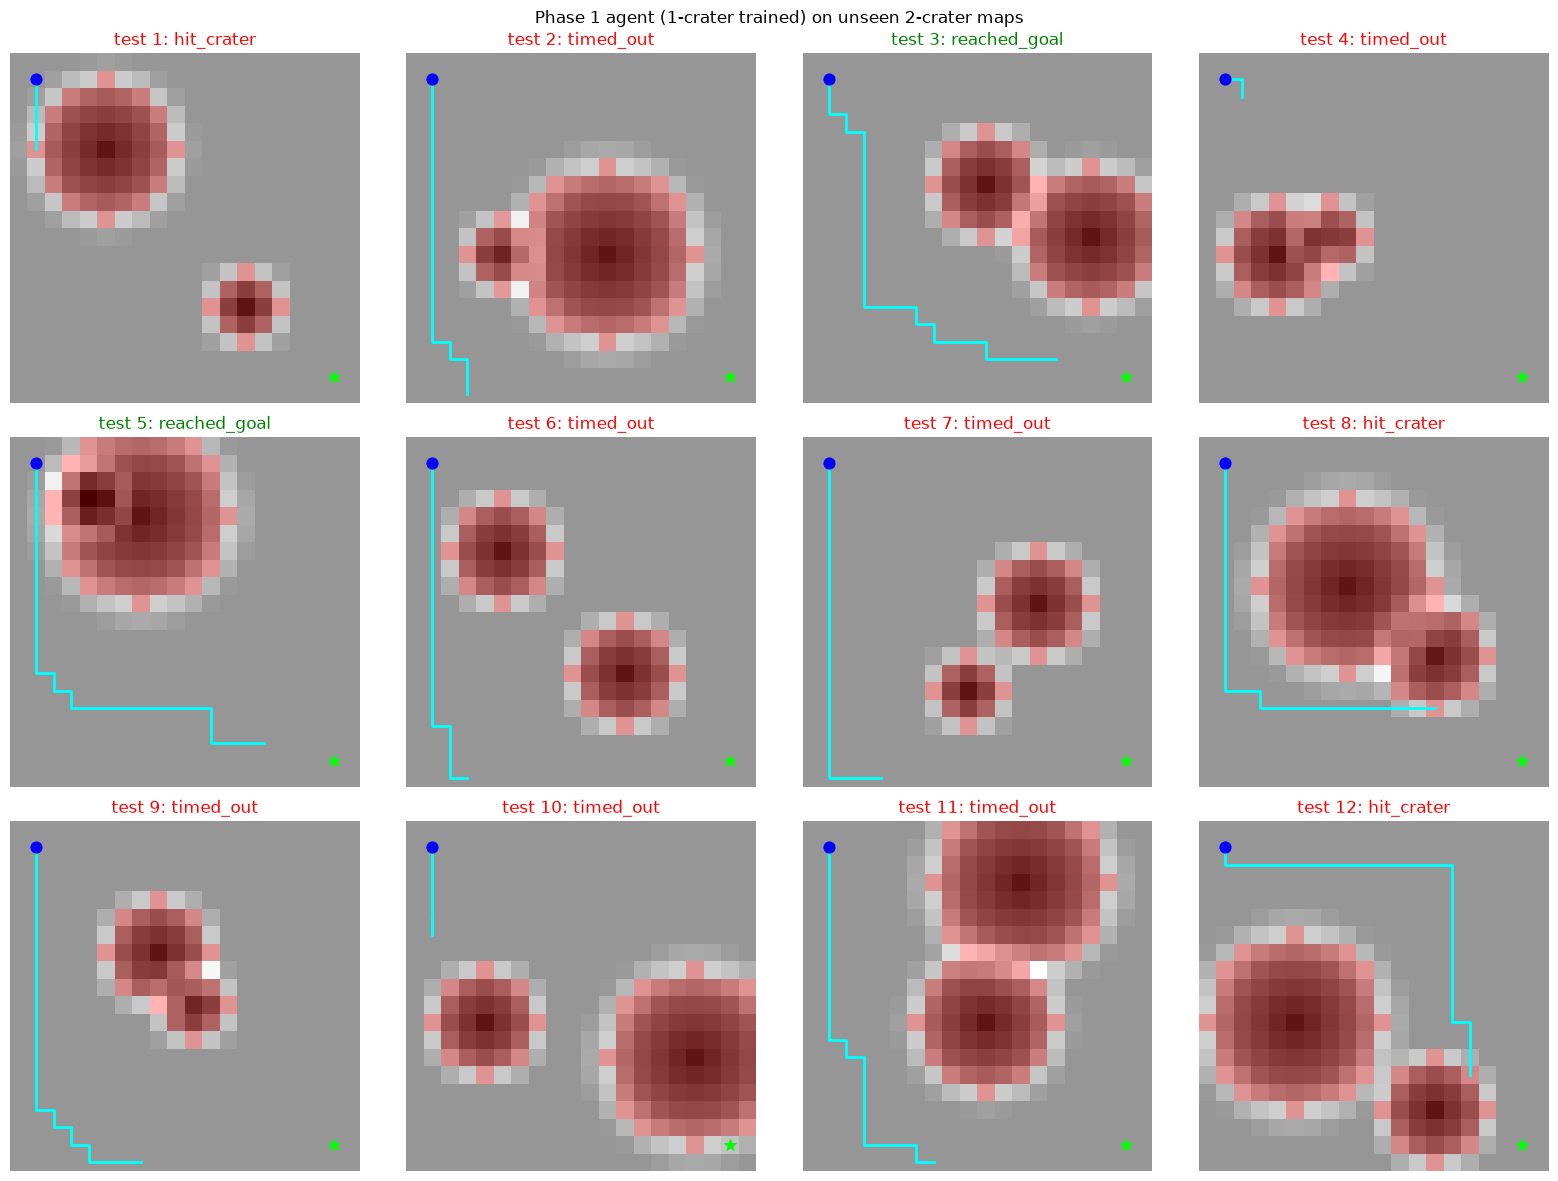

2/12 reached the goal (17%) - Phase 1 agent (1-crater trained) on unseen 2-crater maps
['hit_crater', 'timed_out', 'reached_goal', 'timed_out', 'reached_goal', 'timed_out', 'timed_out', 'hit_crater', 'timed_out', 'timed_out', 'timed_out', 'hit_crater']


In [9]:
test_env_2crater = TinyFixedEnvironment(randomize_crater=True, num_craters=2, seed=999)
_ = run_batch_test(agent, test_env_2crater, title="Phase 1 agent (1-crater trained) on unseen 2-crater maps")

## Phase 2: fine-tune the SAME agent on 2 craters
Continues training the already-1-crater-trained `agent` (same network weights, not a fresh one) on 2-crater maps. Epsilon is boosted back up first since this is a new, harder task, not more of the same - otherwise there'd be almost no exploration left to discover how to handle two craters.

In [13]:
agent.epsilon = 0.5  # boost exploration back up - new, harder task

env2 = TinyFixedEnvironment(randomize_crater=True, num_craters=2)
episodes_phase2 = 400
reward_history_2 = []
outcome_history_2 = []

for ep in range(episodes_phase2):
    state = env2.reset()
    total_reward = 0.0
    done = False
    outcome = "timed_out"
    while not done:
        action = agent.choose_action(state)
        next_state, reward, done, info = env2.step(action)
        agent.replay_buffer.add(state, action, reward, next_state, done)
        agent.train_step()
        state = next_state
        total_reward += reward
        if done:
            if reward == GOAL_REWARD:
                outcome = "reached_goal"
            elif reward == CRATER_PENALTY:
                outcome = "hit_crater"
    agent.decay_epsilon()
    reward_history_2.append(total_reward)
    outcome_history_2.append(outcome)

    if ep % 40 == 0:
        recent = outcome_history_2[-40:]
        success_rate = recent.count("reached_goal") / len(recent) * 100
        print(f"[phase2] Episode {ep}/{episodes_phase2} | Reward: {total_reward:.1f} | success_rate(last40): {success_rate:.0f}%")

print("phase 2 (2-crater fine-tuning) done")

[phase2] Episode 0/400 | Reward: -97.2 | success_rate(last40): 0%
[phase2] Episode 40/400 | Reward: 509.5 | success_rate(last40): 45%
[phase2] Episode 80/400 | Reward: -99.7 | success_rate(last40): 52%
[phase2] Episode 120/400 | Reward: 509.5 | success_rate(last40): 62%
[phase2] Episode 160/400 | Reward: 509.2 | success_rate(last40): 65%
[phase2] Episode 200/400 | Reward: -91.0 | success_rate(last40): 60%
[phase2] Episode 240/400 | Reward: -92.9 | success_rate(last40): 55%
[phase2] Episode 280/400 | Reward: -92.0 | success_rate(last40): 55%
[phase2] Episode 320/400 | Reward: -100.0 | success_rate(last40): 45%
[phase2] Episode 360/400 | Reward: 509.5 | success_rate(last40): 50%
phase 2 (2-crater fine-tuning) done


## Phase 2 reward curve

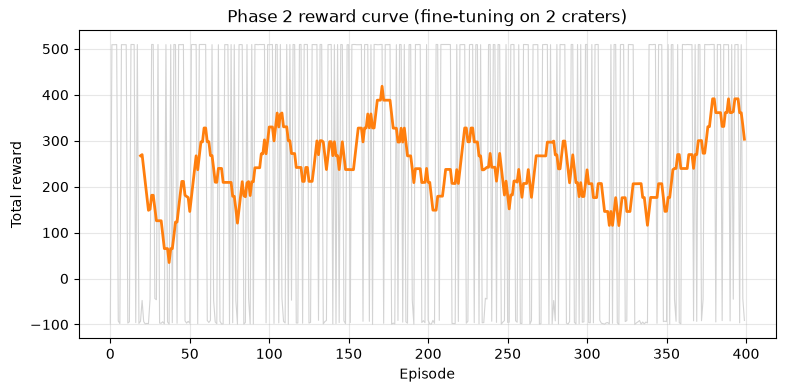

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(reward_history_2, color="lightgray", linewidth=0.8)
window = 20
rolling = np.convolve(reward_history_2, np.ones(window) / window, mode="valid")
ax.plot(range(window - 1, episodes_phase2), rolling, color="tab:orange", linewidth=2)
ax.set_title("Phase 2 reward curve (fine-tuning on 2 craters)")
ax.set_xlabel("Episode"); ax.set_ylabel("Total reward"); ax.grid(alpha=0.3)
display(fig)

## Test the FINE-TUNED agent on 2-crater maps
Compare this success rate against the "Phase 1 agent on unseen 2-crater maps" test above - did fine-tuning actually help?

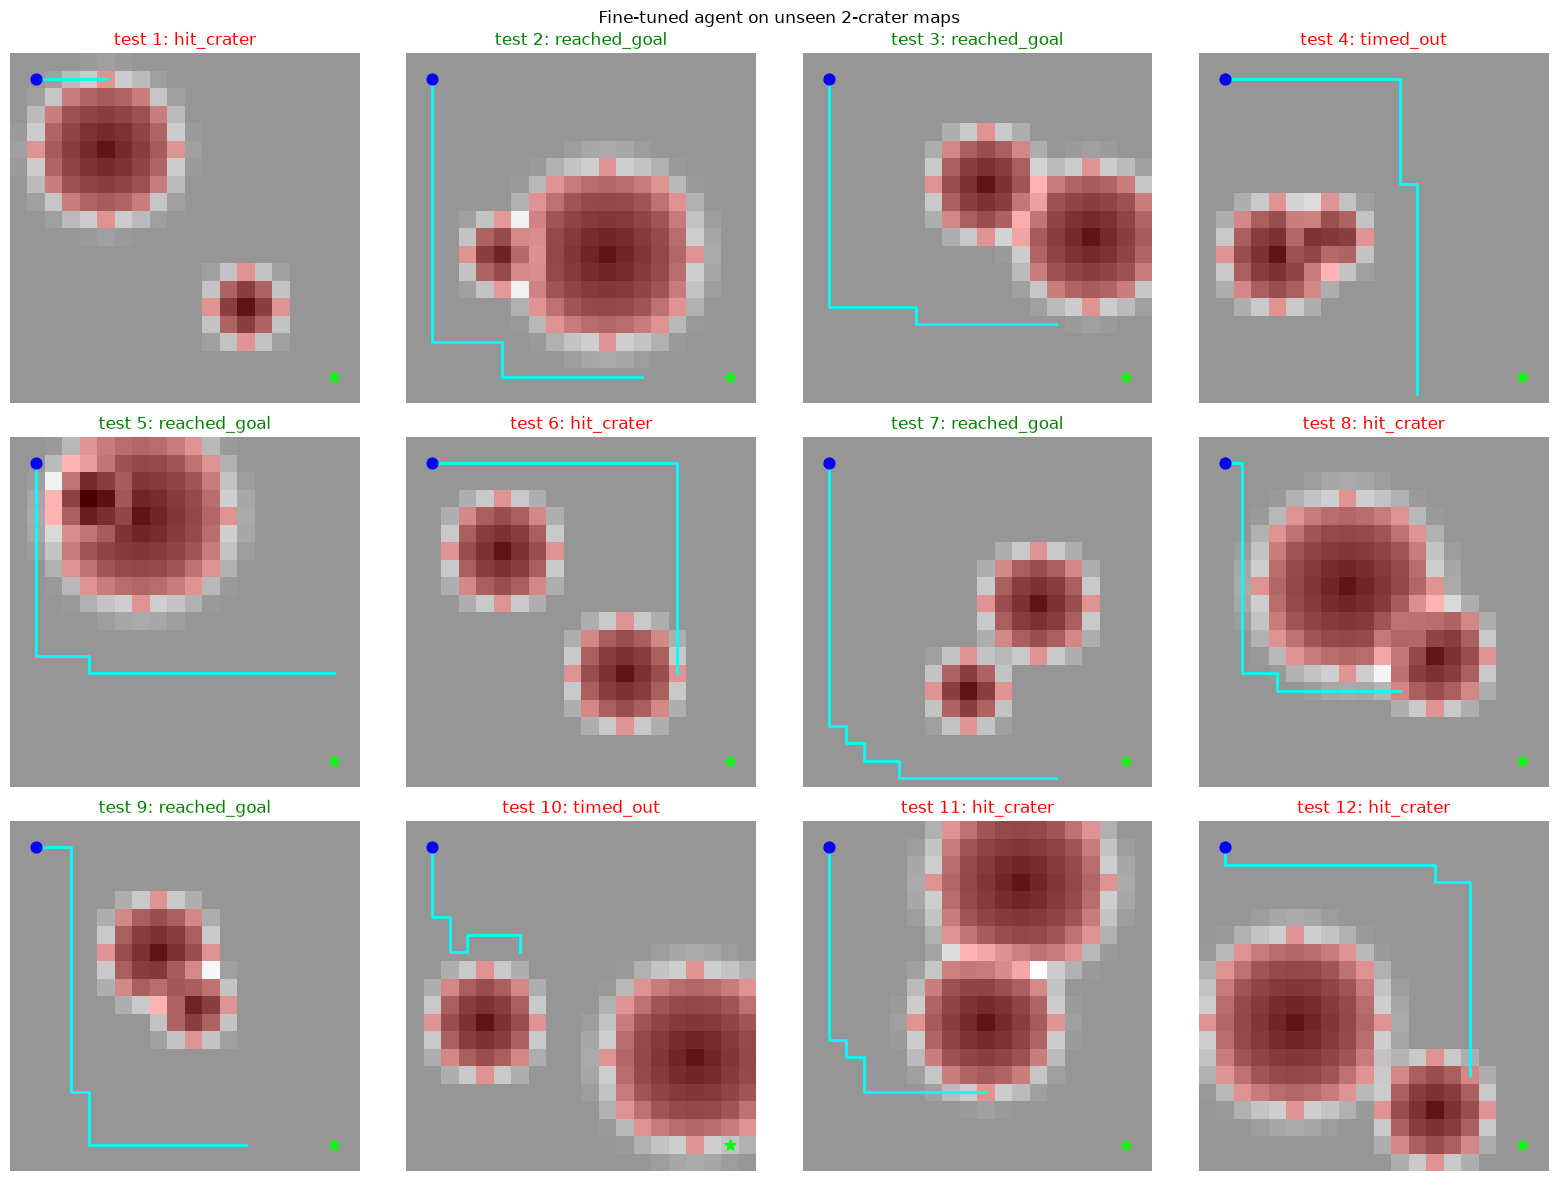

5/12 reached the goal (42%) - Fine-tuned agent on unseen 2-crater maps
['hit_crater', 'reached_goal', 'reached_goal', 'timed_out', 'reached_goal', 'hit_crater', 'reached_goal', 'hit_crater', 'reached_goal', 'timed_out', 'hit_crater', 'hit_crater']


In [15]:
test_env_2crater_after = TinyFixedEnvironment(randomize_crater=True, num_craters=2, seed=999)
_ = run_batch_test(agent, test_env_2crater_after, title="Fine-tuned agent on unseen 2-crater maps")